# Project 3

CALM data storage (Coruscant): /Volumes/data/GradSchool/2025_spring/Environmental_Analytics/Final_Project/working_data

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from libpysal.weights import DistanceBand
from esda.moran import Moran
import matplotlib.pyplot as plt

In [ ]:
# read CSV
df = pd.read_csv("data/calm_all_cleaned.csv")

# create gdf
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# reproject to meters (UTM zone 6N)
gdf = gdf.to_crs(epsg=32606)

# subset to a year (latest year at each location)
latest = gdf.sort_values("year").groupby(["latitude", "longitude"]).tail(1)

# Construct spatial weights matrix (e.g., using 50 km threshold)
w = DistanceBand.from_dataframe(latest, threshold=50000, silence_warnings=True)

# Calculate Moran’s I for ALT
mi = Moran(latest["alt_cm"], w)

# Print results
print(f"Moran's I: {mi.I:.3f}")
print(f"p-value: {mi.p_sim:.4f}")

Moran's I: nan
p-value: 0.0010


Check for missing or constant ALT values

In [27]:
print(latest["alt_cm"].isna().sum()) # count of missing values
print(latest["alt_cm"].nunique())  # count of unique values
print(latest["alt_cm"].describe())  # summary stats

164
126
count    683.000000
mean      45.635432
std       15.280741
min       21.500000
25%       35.000000
50%       42.000000
75%       52.500000
max      117.000000
Name: alt_cm, dtype: float64


Moran’s I is not due to constant values.

---

histogram to check variability

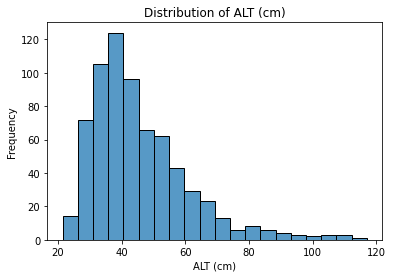

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(latest["alt_cm"], bins=20)
plt.title("Distribution of ALT (cm)")
plt.xlabel("ALT (cm)")
plt.ylabel("Frequency")
plt.show()